# 15. Финальная визуализация результатов

Этот ноутбук использует **только результаты финальной модели `resolution = 1.25`**.

Цель - собрать конкурсные визуализации, которые отвечают трем задачам проекта:

1. Показать экономические профили устойчивых типов муниципалитетов;
2. Показать изменение структуры типов во времени;
3. Показать качество и устойчивость выбранной конфигурации.

Все графики сохраняются в `outputs/figures/`. Интерактивная Sankey-диаграмма сохраняется в HTML.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
except ImportError:
    go = None

cwd = Path.cwd()
project_root = None
for path in [cwd, *cwd.parents]:
    if (path / "data" / "processed").exists() or (path / "outputs").exists():
        project_root = path
        break
if project_root is None:
    project_root = cwd.parent

processed = project_root / "data" / "processed"
figures = project_root / "outputs" / "figures"
figures.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "food_share",
    "health_share",
    "marketplaces_share",
    "catering_share",
    "transport_share"
]
FEATURE_NAMES = {
    "food_share": "Продовольствие",
    "health_share": "Здоровье",
    "marketplaces_share": "Маркетплейсы",
    "catering_share": "Общественное питание",
    "transport_share": "Транспорт"
}
TYPE_ORDER = [
    "Маркетплейсно-ориентированный",
    "Диверсифицированный сервисный",
    "Продовольственный"
]

print("Проект:", project_root)
print("processed:", processed)


Проект: /Users/abrenmarie/Documents/00_AM/06_PROJECTS/municipality_clustering
processed: /Users/abrenmarie/Documents/00_AM/06_PROJECTS/municipality_clustering/data/processed


## 1. Загрузка финальных результатов

`14_final_model_125` сохраняет типологию для каждого наблюдения `муниципалитет-месяц`. Дополнительно используются месячные сводки и результаты оценки финальной модели.


In [2]:
final_types = pd.read_parquet(processed / "municipality_economic_types_final.parquet")
monthly_summary = pd.read_csv(processed / "final_monthly_summary_resolution_125.csv")
profiles = pd.read_csv(processed / "economic_type_profiles_final_125.csv", index_col=0)
k_validation = pd.read_csv(processed / "economic_type_k_validation_final_125.csv") if (processed / "economic_type_k_validation_final_125.csv").exists() else None
monthly_shares = pd.read_csv(processed / "monthly_economic_type_shares_final_125.csv") if (processed / "monthly_economic_type_shares_final_125.csv").exists() else None
transitions = pd.read_csv(processed / "economic_type_transitions_final_125.csv") if (processed / "economic_type_transitions_final_125.csv").exists() else None
comparison = pd.read_csv(processed / "method_comparison_full_final.csv") if (processed / "method_comparison_full_final.csv").exists() else None
stability = pd.read_csv(processed / "louvain_stability_dec2024.csv") if (processed / "louvain_stability_dec2024.csv").exists() else None

print("Наблюдений:", len(final_types))
print("Месяцев:", final_types["date"].nunique())
print("Типов:", final_types["economic_type"].nunique())


Наблюдений: 50521
Месяцев: 24
Типов: 3


## 2. Профили трех устойчивых экономических типов

Здесь сравнивается структура пяти потребительских долей. Названия типов являются описательными и получены из самих профилей, а не являются официальной классификацией муниципалитетов.


NameError: name 'PercentFormatter' is not defined

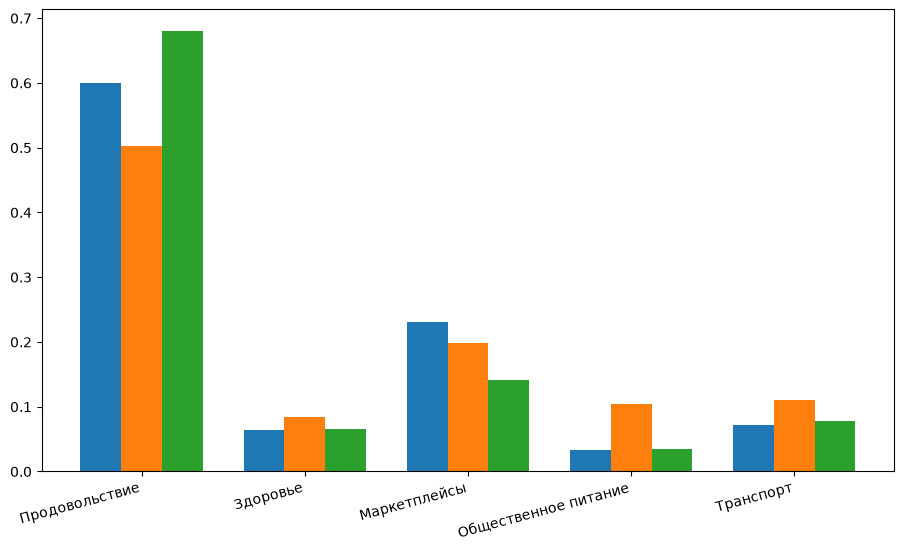

In [3]:
profile_plot = profiles.reindex(TYPE_ORDER)[FEATURES].copy()
profile_plot.columns = [FEATURE_NAMES[c] for c in profile_plot.columns]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(profile_plot.columns))
width = 0.25
for i, idx in enumerate(profile_plot.index):
    ax.bar(x + (i-1)*width, profile_plot.loc[idx].values, width=width, label=idx)

ax.set_xticks(x)
ax.set_xticklabels(profile_plot.columns, rotation=15, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Средняя доля")
ax.set_title("Профили устойчивых экономических типов")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(figures / "final_type_profiles.png", dpi=220, bbox_inches="tight")
plt.show()


## 3. Размеры экономических типов

Показываем распределение всех `муниципалитет-месяц` наблюдений между тремя устойчивыми типами, их долевое представительство в панели.


In [ ]:
type_sizes = (
    final_types.groupby(["economic_type", "economic_type_name"])
    .size()
    .reset_index(name="n_observations")
)
type_sizes["share"] = type_sizes["n_observations"] / type_sizes["n_observations"].sum()
type_sizes = type_sizes.sort_values("economic_type")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(type_sizes["economic_type_name"], type_sizes["share"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Доля наблюдений")
ax.set_title("Размер устойчивых экономических типов в панели")
ax.tick_params(axis="x", rotation=15)
for bar, value in zip(bars, type_sizes["share"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{value:.1%}", ha="center")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(figures / "final_type_sizes.png", dpi=220, bbox_inches="tight")
plt.show()


## 4. Динамика числа месячных кластеров и modularity

Количество локальных кластеров меняется от месяца к месяцу, а modularity показывает, насколько хорошо месячная сеть разделяется на сообщества при фиксированном `resolution = 1.25`.


In [ ]:
monthly_summary = monthly_summary.copy()
monthly_summary["date"] = pd.to_datetime(monthly_summary["date"])

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.plot(monthly_summary["date"], monthly_summary["n_clusters"], marker="o", label="Число кластеров")
ax1.set_ylabel("Число кластеров")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(monthly_summary["date"], monthly_summary["modularity"], marker="s", linestyle="--", label="Modularity")
ax2.set_ylabel("Modularity")

ax1.set_title("Динамика структуры экономической сети, 2023-01 - 2024-12")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(figures / "final_monthly_network_dynamics.png", dpi=220, bbox_inches="tight")
plt.show()


## 5. Динамика долей устойчивых типов

После перехода от месячных кластеров к устойчивым экономическим типам можно отслеживать изменение структуры панели во времени.


In [ ]:
if monthly_shares is None:
    raise FileNotFoundError(
        "Не найден monthly_economic_type_shares_final_125.csv. "
        "Сначала выполните 14_final_model_125.ipynb."
    )

monthly_shares["date"] = pd.to_datetime(monthly_shares["date"])

fig, ax = plt.subplots(figsize=(11, 6))
for name in TYPE_ORDER:
    if name in monthly_shares.columns:
        ax.plot(monthly_shares["date"], monthly_shares[name], marker="o", markersize=3, label=name)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Доля муниципалитетов")
ax.set_title("Динамика долей устойчивых экономических типов")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(figures / "final_type_dynamics.png", dpi=220, bbox_inches="tight")
plt.show()


## 6. Переходы между устойчивыми типами

Sankey показывает агрегированную структуру переходов между экономическими типами в соседних месяцах. Для интерактивного графика используется Plotly.


In [ ]:
if transitions is not None and go is not None:
    flow = (
        transitions
        .groupby(["type_from_name", "type_to_name"], as_index=False)["n_municipalities"]
        .sum()
    )

    labels = TYPE_ORDER
    label_to_idx = {x:i for i,x in enumerate(labels)}
    source = [label_to_idx[x] for x in flow["type_from_name"]]
    target = [label_to_idx[x] for x in flow["type_to_name"]]
    value = flow["n_municipalities"].tolist()

    fig = go.Figure(go.Sankey(
        node=dict(label=labels, pad=22, thickness=18),
        link=dict(source=source, target=target, value=value)
    ))
    fig.update_layout(
        title="Переходы муниципалитетов между устойчивыми экономическими типами",
        font=dict(size=12)
    )
    fig.write_html(figures / "final_type_sankey.html", include_plotlyjs="cdn")
    fig.show()
else:
    print("Sankey будет построен после выполнения 14 и установки plotly.")


## 7. Сравнение Euclidean и Cosine на декабре 2024

Обе метрики строятся на одинаковых пяти признаках и одном `k = 10`. В controlled comparison для Cosine используется единый глобальный параметр RBF `sigma`, чтобы различалась именно мера расстояния.


In [ ]:
if comparison is not None:
    c = comparison[comparison["resolution"] == 1.25].copy()
    metrics = ["modularity", "silhouette", "calinski_harabasz"]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    for ax, metric in zip(axes, metrics):
        vals = c.pivot(index="method", columns="resolution", values=metric)[1.25]
        vals.plot(kind="bar", ax=ax, legend=False)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle("Euclidean vs Cosine при resolution = 1.25", y=1.02)
    fig.tight_layout()
    fig.savefig(figures / "final_method_comparison_125.png", dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("Файл сравнения будет создан после выполнения 13_method_comparison.ipynb.")


## 8. Устойчивость Louvain к случайному seed

Сравниваем средний, минимальный и максимальный ARI между пятью запусками для каждого `resolution`. Это диагностическая проверка устойчивости сетевого разбиения.


In [ ]:
if stability is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(
        stability["resolution"],
        stability["ARI_mean"],
        yerr=[
            stability["ARI_mean"] - stability["ARI_min"],
            stability["ARI_max"] - stability["ARI_mean"]
        ],
        fmt="o-",
        capsize=4
    )
    ax.set_xlabel("Louvain resolution")
    ax.set_ylabel("ARI")
    ax.set_title("Устойчивость сетевой кластеризации к seed")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(figures / "final_louvain_stability.png", dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("Файл stability будет создан после выполнения 12_icvi_evaluation.ipynb.")


## 9. Итоговая таблица финальной модели

Эта таблица удобна для переноса в README и презентацию.


In [ ]:
evaluation_path = processed / "final_model_evaluation.csv"
if evaluation_path.exists():
    final_evaluation = pd.read_csv(evaluation_path)
    display(final_evaluation)
else:
    print("final_model_evaluation.csv появится после выполнения 14_final_model_125.ipynb.")


## Финальный вывод

Финальная визуализация объединяет атрибутивную и сетевую части модели: экономические профили описывают содержание типов, временные графики показывают их динамику, а сравнение методов и seed-stability фиксируют обоснованность выбранной конфигурации `resolution = 1.25`.
